Скачивание датасета и выбор из него нужных классов

In [ ]:
import os
import shutil
from PIL import Image

!pip install ultralytics kaggle -q
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d kushagrapandya/visdrone-dataset
!unzip -q visdrone-dataset.zip

CLASS_MAP = {
    4: 0,   # car
    5: 1,   # van
    6: 2,   # truck
    8: 3,   # awning-tricycle
    9: 4,   # bus
    10: 5,  # motor
}

def filter_and_convert(split, src_name):
    ann_in  = f"{src_name}/annotations"
    img_in  = f"{src_name}/images"
    ann_out = f"visdrone_filtered/{split}/labels"
    img_out = f"visdrone_filtered/{split}/images"

    os.makedirs(ann_out, exist_ok=True)
    os.makedirs(img_out, exist_ok=True)

    converted, skipped = 0, 0

    for ann_file in sorted(os.listdir(ann_in)):
        if not ann_file.endswith(".txt"):
            continue

        img_name = ann_file.replace(".txt", ".jpg")
        img_path = os.path.join(img_in, img_name)
        if not os.path.exists(img_path):
            continue

        img = Image.open(img_path)
        img_w, img_h = img.size

        yolo_lines = []
        with open(os.path.join(ann_in, ann_file)) as f:
            for line in f:
                parts = line.strip().split(",")
                if len(parts) < 6:
                    continue
                x, y, w, h = int(parts[0]), int(parts[1]), int(parts[2]), int(parts[3])
                cat = int(parts[5])

                if cat not in CLASS_MAP or w == 0 or h == 0:
                    continue

                cx = (x + w / 2) / img_w
                cy = (y + h / 2) / img_h
                nw = w / img_w
                nh = h / img_h

                yolo_lines.append(
                    f"{CLASS_MAP[cat]} {cx:.6f} {cy:.6f} {nw:.6f} {nh:.6f}"
                )

        if yolo_lines:
            with open(os.path.join(ann_out, ann_file), "w") as f:
                f.write("\n".join(yolo_lines))
            shutil.copy(img_path, img_out)
            converted += 1
        else:
            skipped += 1

filter_and_convert("train", "VisDrone2019-DET-train/VisDrone2019-DET-train")
filter_and_convert("val",   "VisDrone2019-DET-val/VisDrone2019-DET-val")



cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/kushagrapandya/visdrone-dataset
License(s): GNU Affero General Public License 3.0
visdrone-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
replace VisDrone.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: ^C


KeyboardInterrupt: 

Создание yaml файла для этих 6 классов

In [ ]:
yaml_content = """
path: /kaggle/working/visdrone_filtered
train: train/images
val: val/images

nc: 6
names:
  0: car
  1: van
  2: truck
  3: awning-tricycle
  4: bus
  5: motor
"""

with open("VisDrone_filtered.yaml", "w") as f:
    f.write(yaml_content)


Обучение yolo11x

In [ ]:
from ultralytics import YOLO
model = YOLO('yolo11x.pt')
model.train(
    data='/kaggle/working/VisDrone_filtered.yaml',
    epochs=15,
    imgsz=1024,
    batch=10,
    optimizer='AdamW',
    lr0=0.001,
    lrf=0.01,
    weight_decay=0.0005,
    warmup_epochs=5,
    warmup_momentum=0.8,
    warmup_bias_lr=0.1,
    hsv_h=0.015, hsv_s=0.7, hsv_v=0.4,
    degrees=0.0,
    translate=0.1,
    scale=0.5,
    shear=0.0,
    perspective=0.0,
    flipud=0.5,
    fliplr=0.5,
    mosaic=1.0,
    mixup=0.4,
    close_mosaic=15,
    cos_lr=True,
    save=True,
    save_period=1,
    dropout=0.1,
    val=True,
    device=[0, 1],
    amp=True,
    seed=42,
)

Ultralytics 8.4.66 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=10, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=15, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=True, cutmix=0.0, data=/kaggle/working/VisDrone_filtered.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.1, dynamic=False, embed=None, end2end=None, epochs=15, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.5, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=1024, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.4, mode=train, model=yolo11x.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train-11, 

Графики обучения

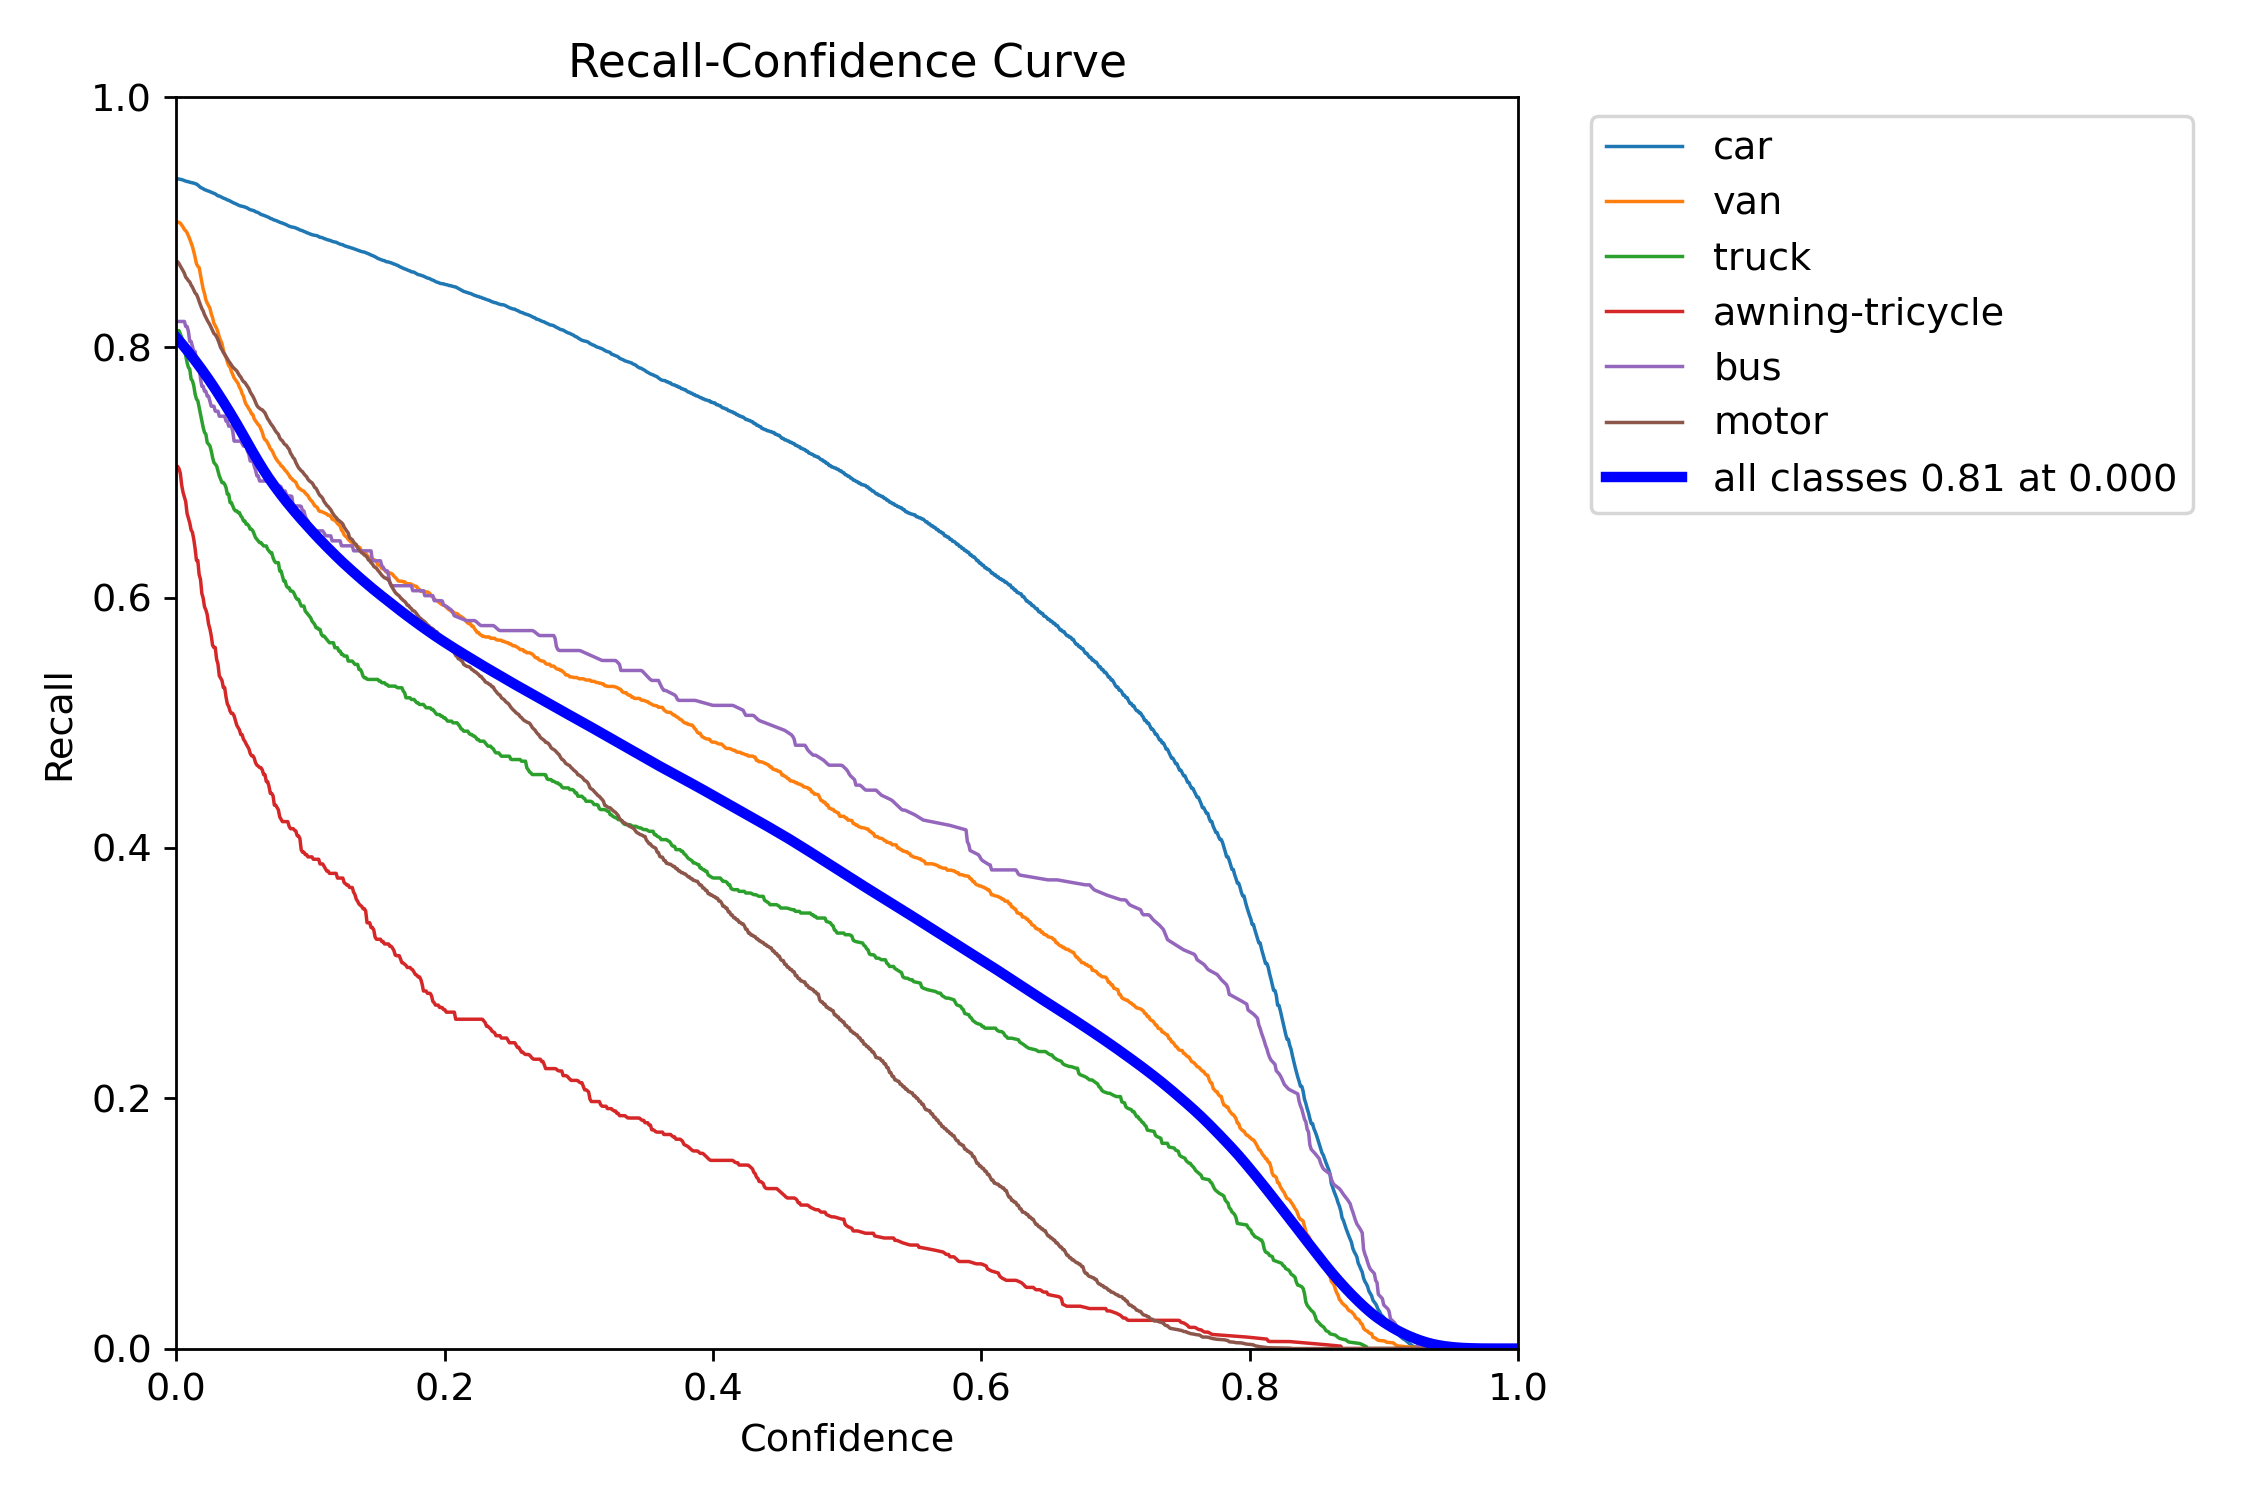

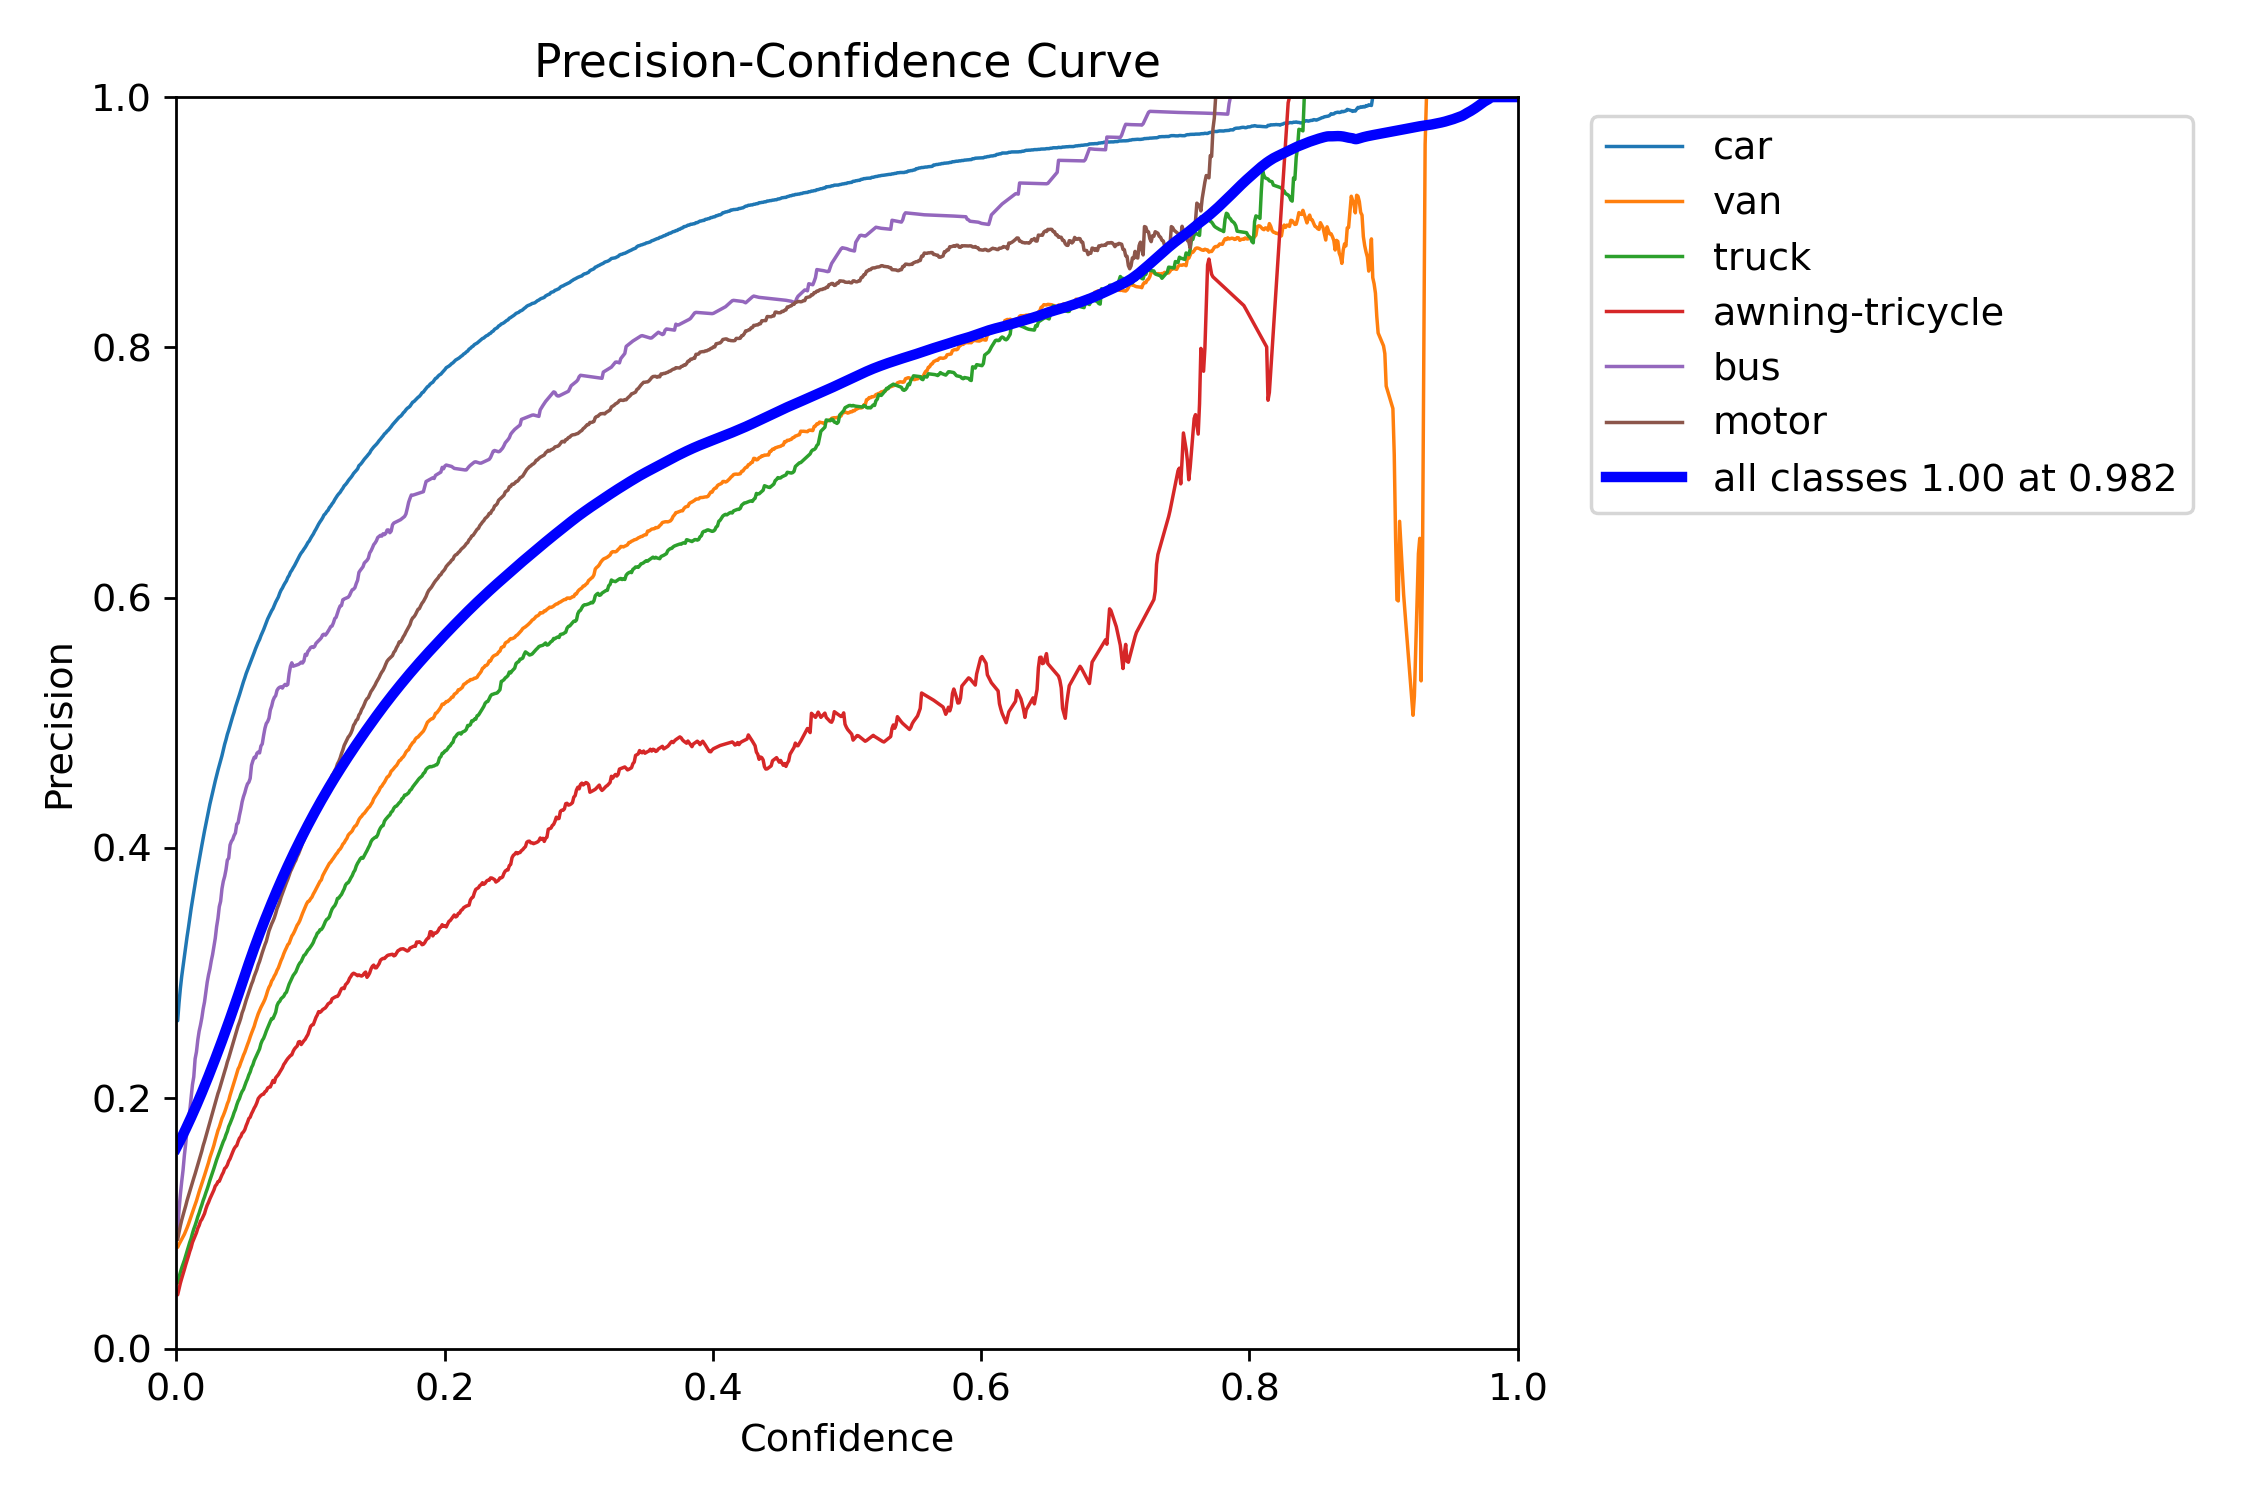

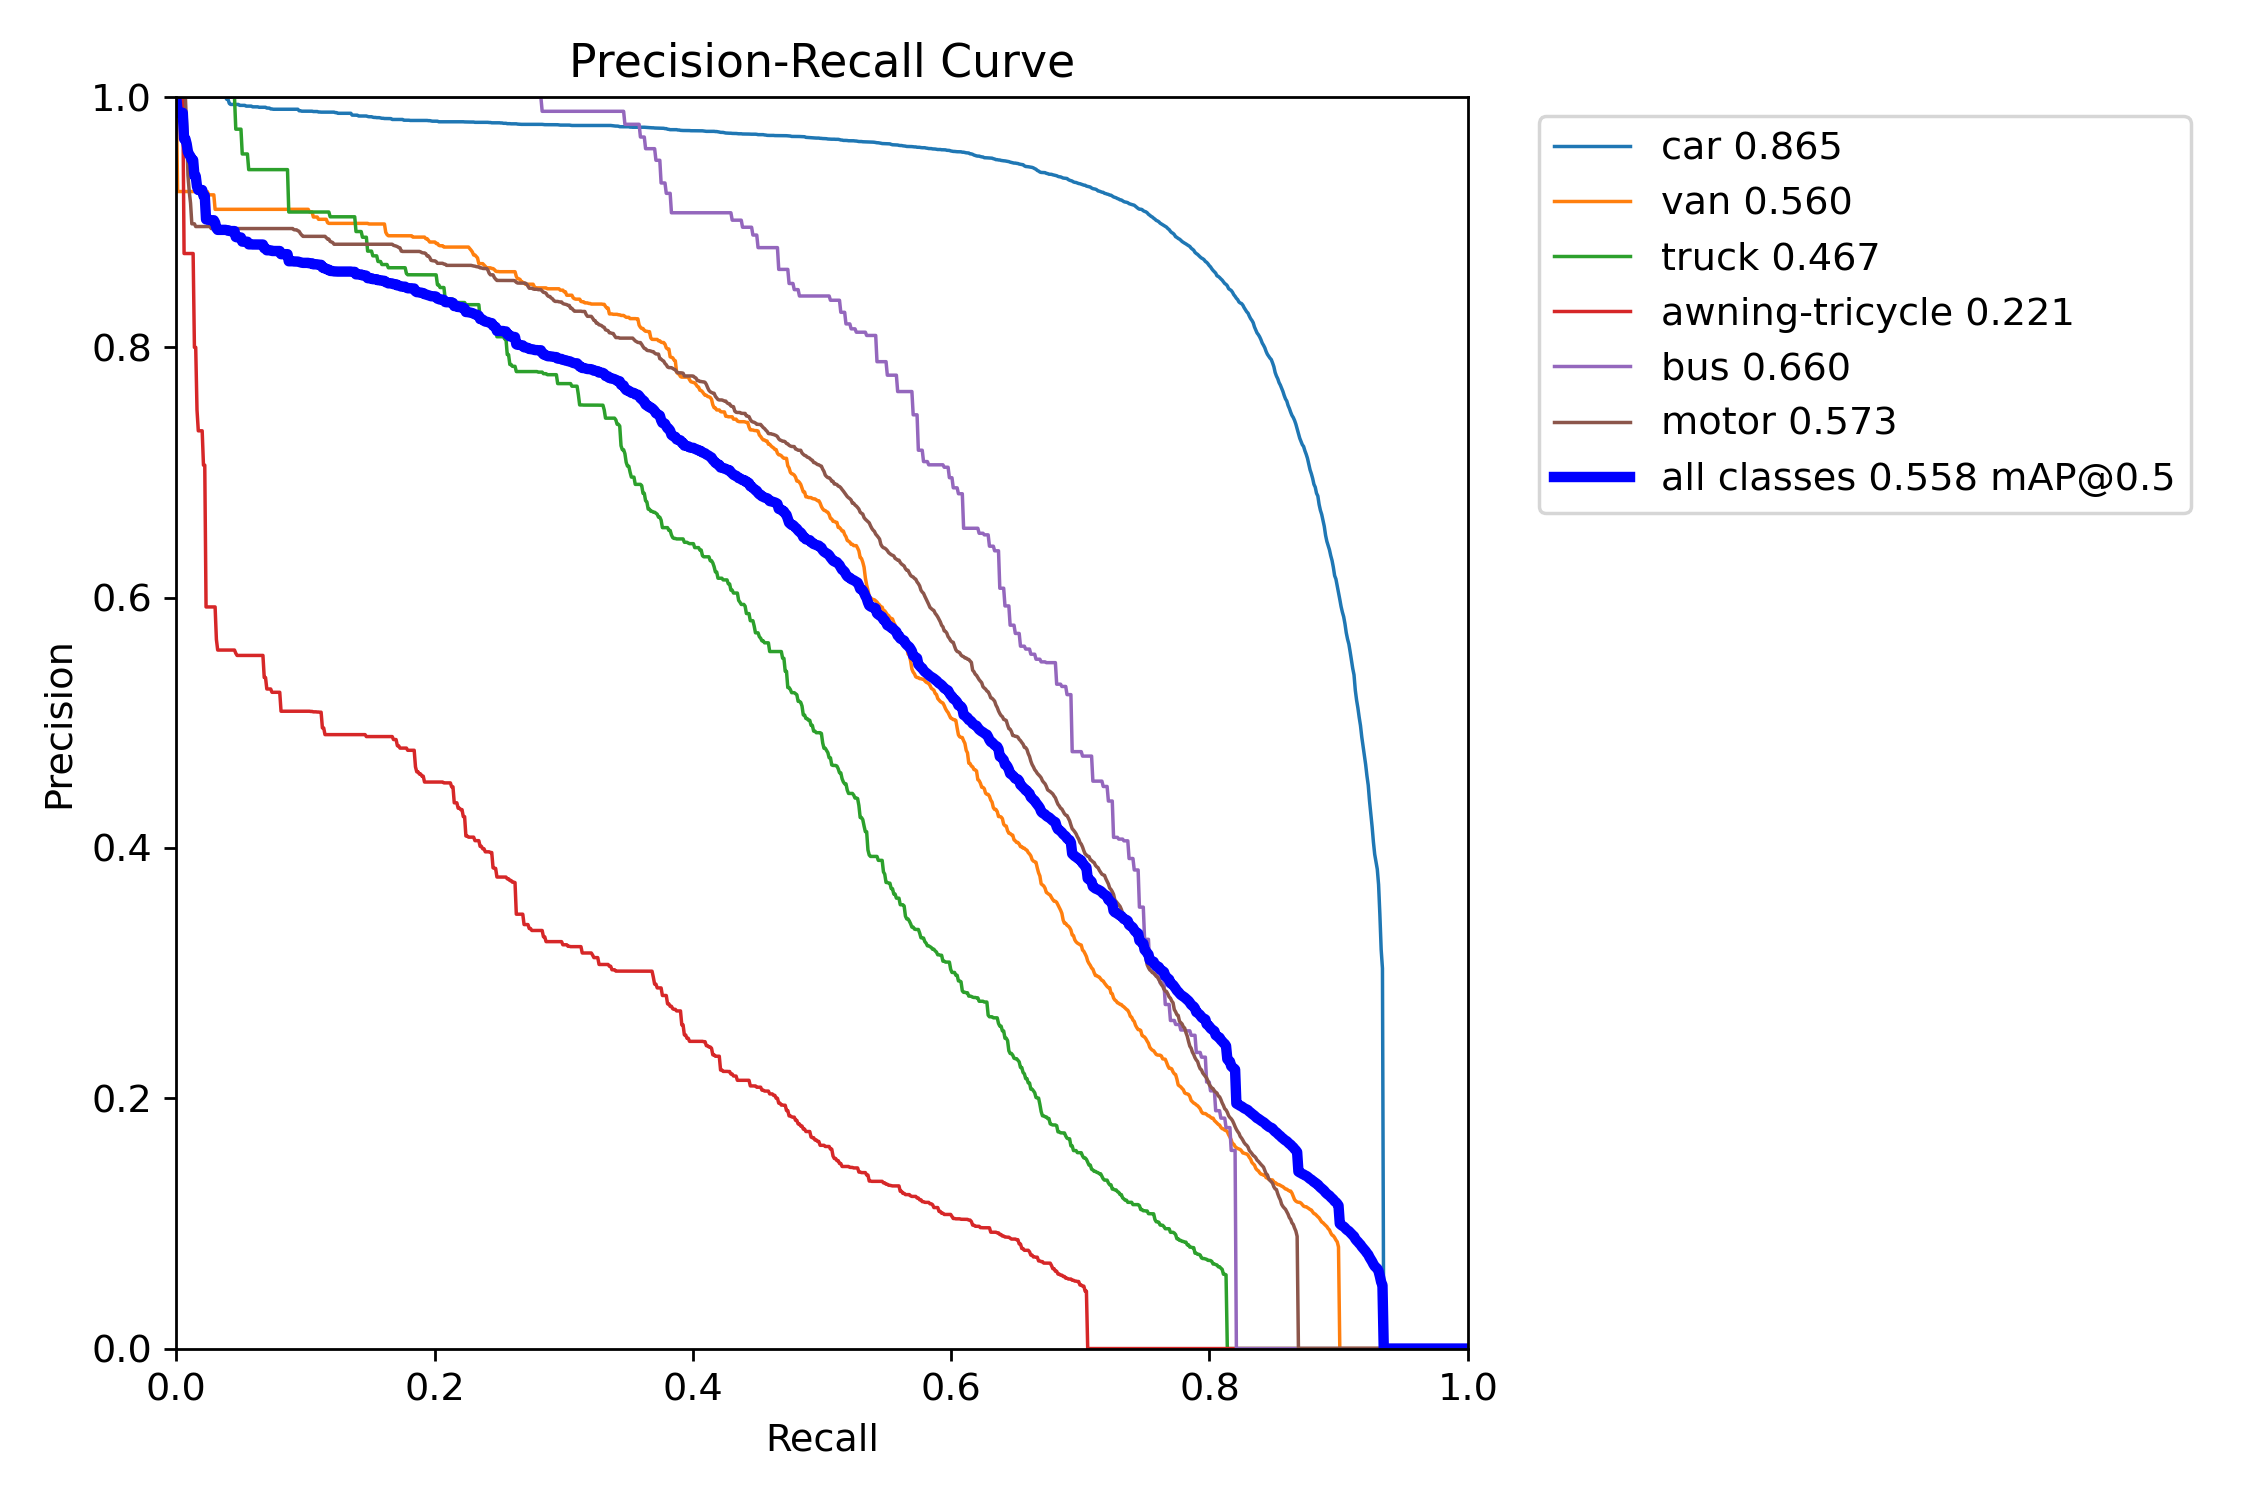

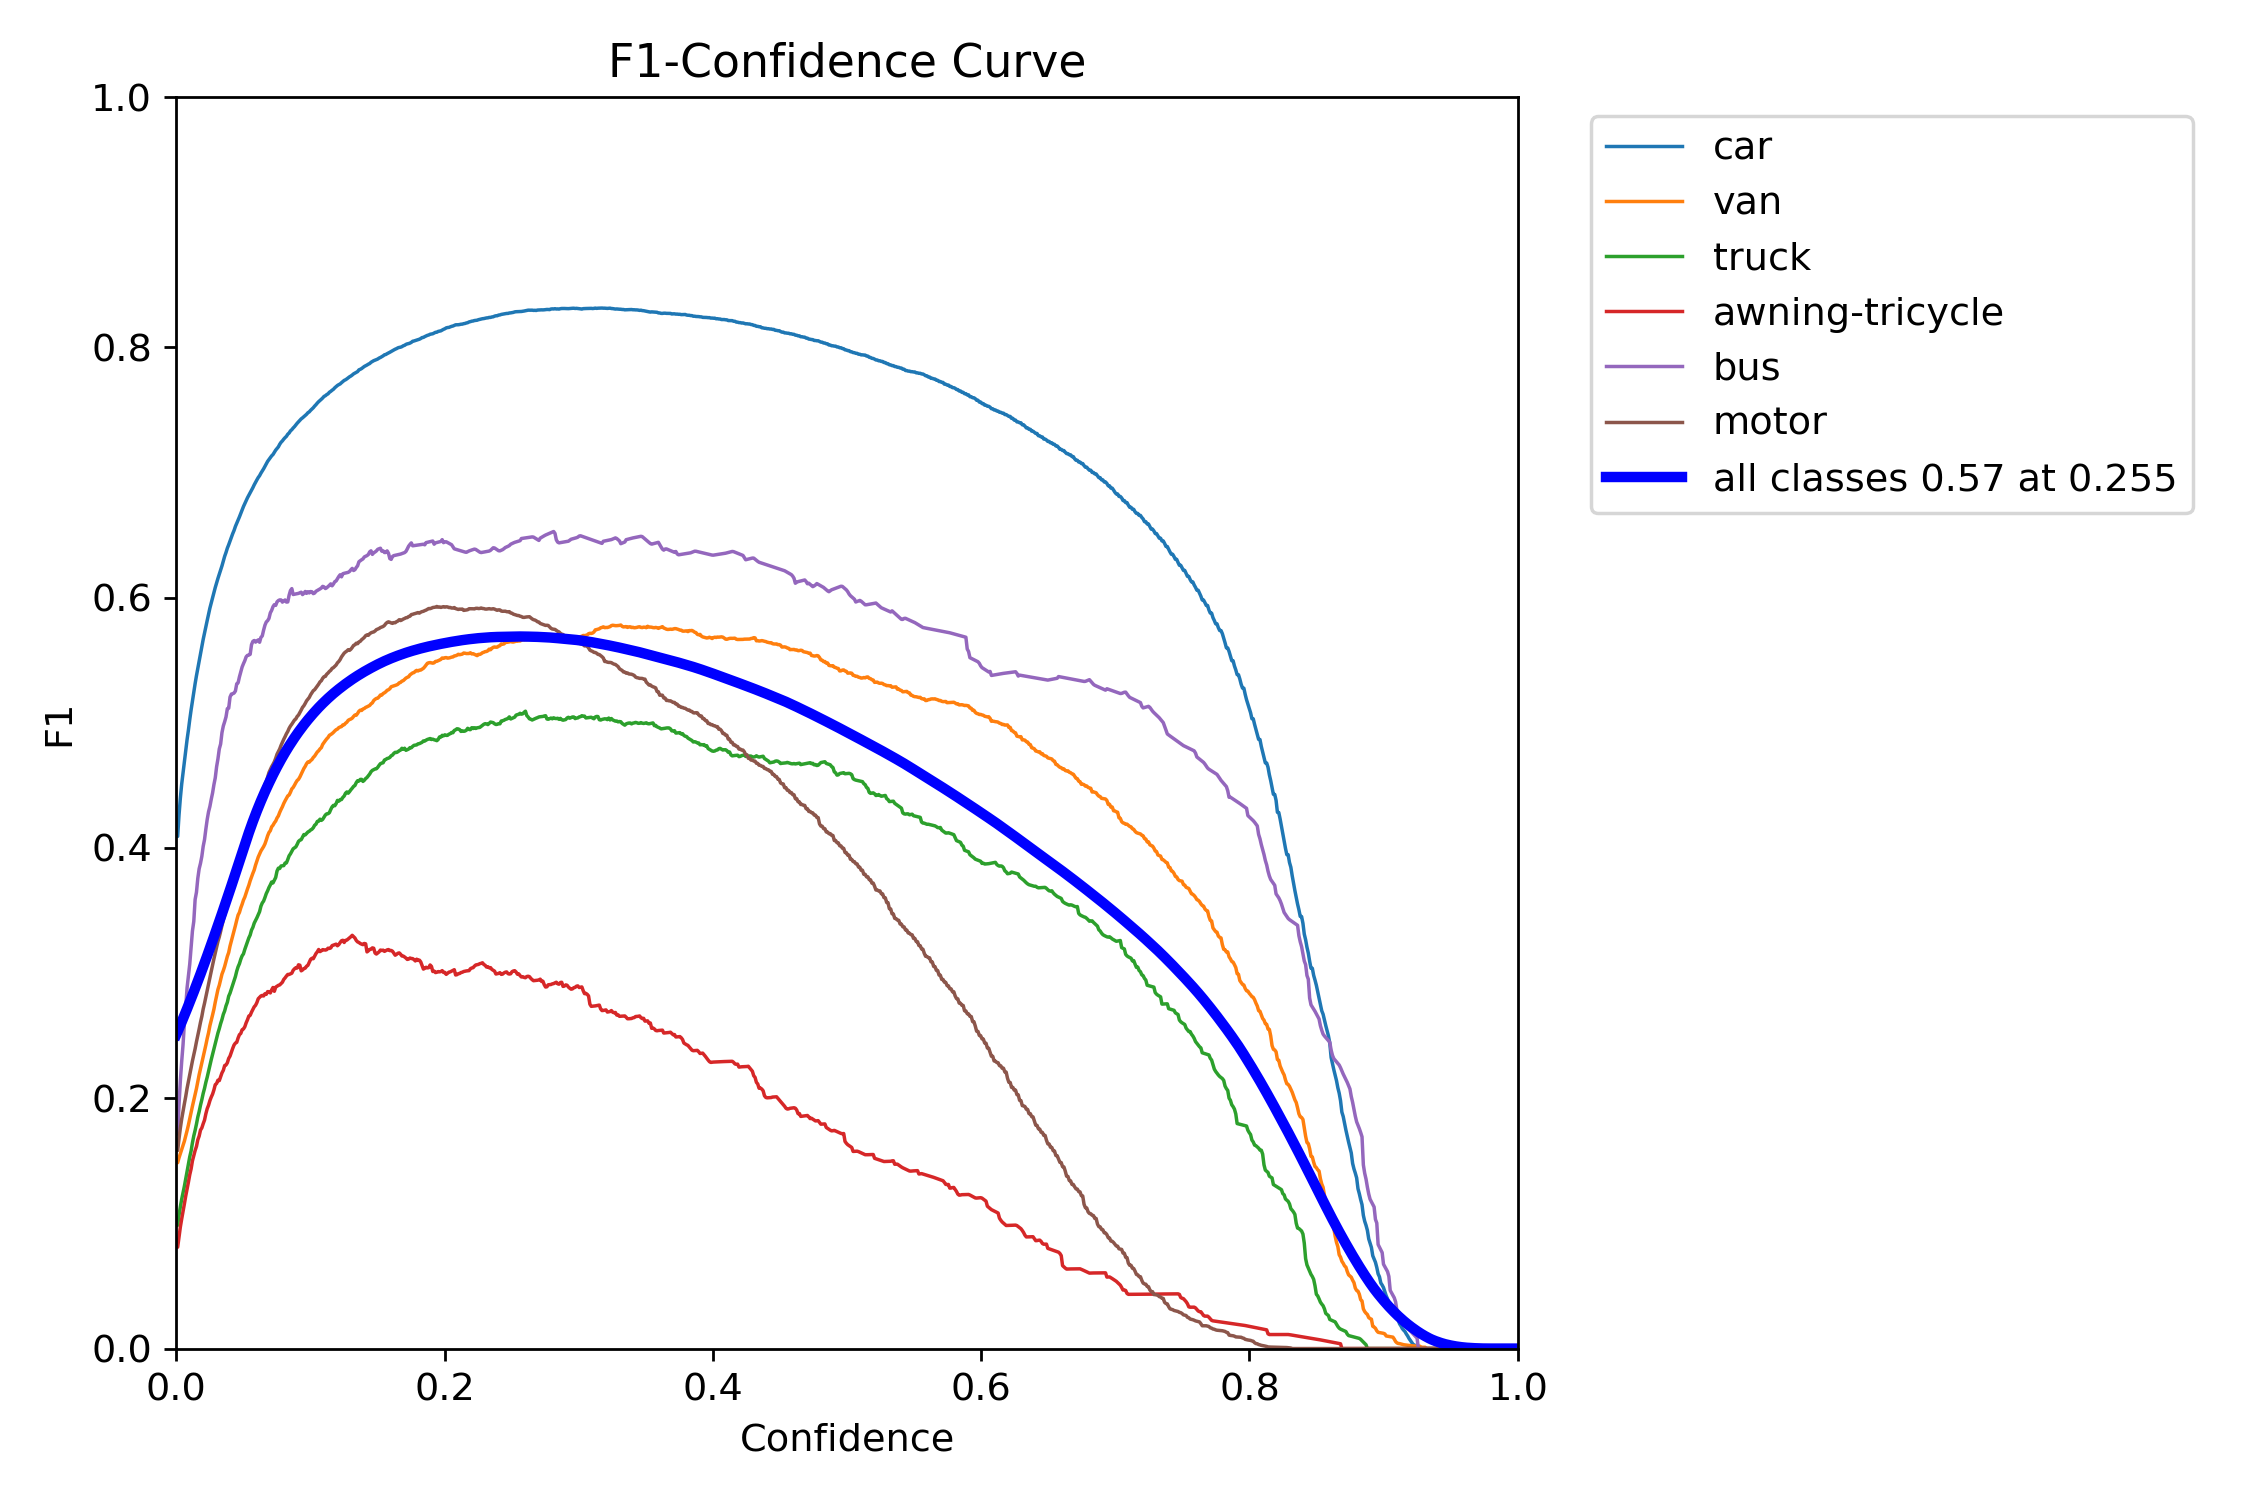